In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st

## Portfolio assignment 3

Hier is een univariate analyse van alle categorische gegevens in de penguins-dataset.

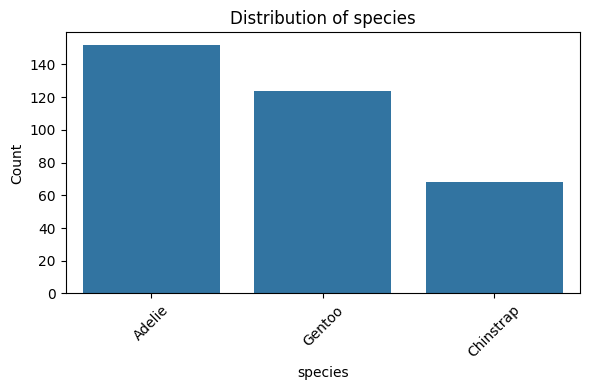

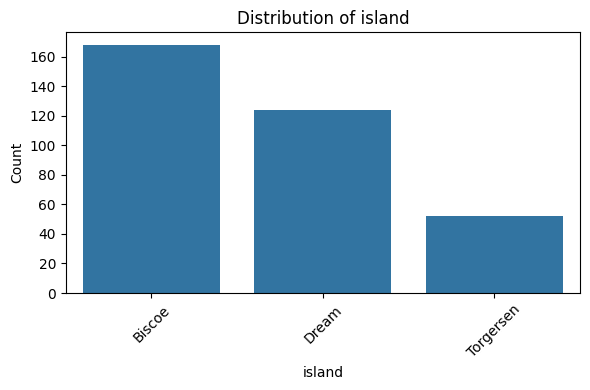

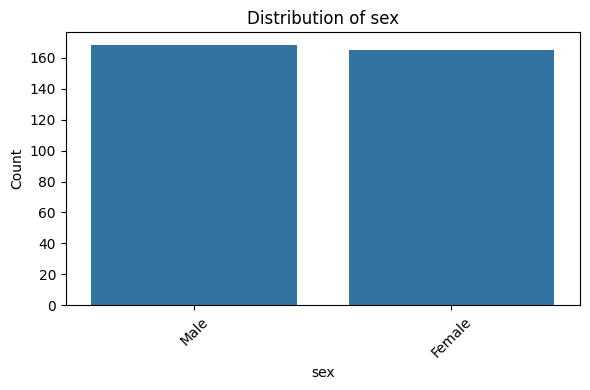

In [59]:
penguins = sns.load_dataset("penguins")

# Selecting all the categorical columns in the dataset
categorical_cols = penguins.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=penguins, x=col, order=penguins[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Findings:** Uit mijn grafieken blijkt dat er drie kolommen in de dataset categorisch zijn. We zien dat de soort Adelie het meest voorkomt in de dataset. Ook is te zien dat we de minste gegevens hebben voor de pinguïns op het eiland Torgersen. Tot slot kunnen we concluderen dat het aantal mannelijke en vrouwelijke pinguïns in de dataset vrijwel gelijk is.

## Portfolio assignment 4

In [23]:
cybersecurityThreats = pd.read_csv('dataset/Global_Cybersecurity_Threats.csv', sep=',')

print(f"Aantal rijen: {len(cybersecurityThreats)}")
print(f"Aantal kolommen met categorische gegevens: {cybersecurityThreats.select_dtypes(include=['object', 'category']).shape[1]}")
print(f"Aantal kolommen met numerieke gegevens: {cybersecurityThreats.select_dtypes(include=['number']).shape[1]}")

size_in_mb = cybersecurityThreats.memory_usage(deep=True).sum() / 1024**2
print(f"Dataset groote: {size_in_mb:.2f} MB")

cybersecurityThreats.head()

Aantal rijen: 3000
Aantal kolommen met categorische gegevens: 6
Aantal kolommen met numerieke gegevens: 4
Dataset groote: 1.10 MB


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


## Portfolio assignment 5

In [86]:
lifeExpectancy = pd.read_csv('dataset/lifeExpectancyAtBirth.csv', sep=',')

lifeExpectancy.head()

,Location,Period,Indicator,Dim1,First Tooltip
0,Afghanistan,2019,Life expectancy at birth (years),Both sexes,63.21
1,Afghanistan,2019,Life expectancy at birth (years),Male,63.29
2,Afghanistan,2019,Life expectancy at birth (years),Female,63.16
3,Afghanistan,2015,Life expectancy at birth (years),Both sexes,61.65
4,Afghanistan,2015,Life expectancy at birth (years),Male,61.04


### Univariate analyse van de levensverwachting in 2019

In [87]:
filtered_df = lifeExpectancy[
    (lifeExpectancy['Period'] == 2019) & 
    (lifeExpectancy['Dim1'] == 'Both sexes')
]

filtered_df.head()

,Location,Period,Indicator,Dim1,First Tooltip
0,Afghanistan,2019,Life expectancy at birth (years),Both sexes,63.21
12,Albania,2019,Life expectancy at birth (years),Both sexes,78.00
24,Algeria,2019,Life expectancy at birth (years),Both sexes,77.13
36,Angola,2019,Life expectancy at birth (years),Both sexes,63.06
48,Antigua and Barbuda,2019,Life expectancy at birth (years),Both sexes,76.45


count    183.000000
mean      72.540492
std        7.129956
min       50.750000
25%       66.550000
50%       73.740000
75%       77.730000
max       84.260000
Name: First Tooltip, dtype: float64


<Axes: >

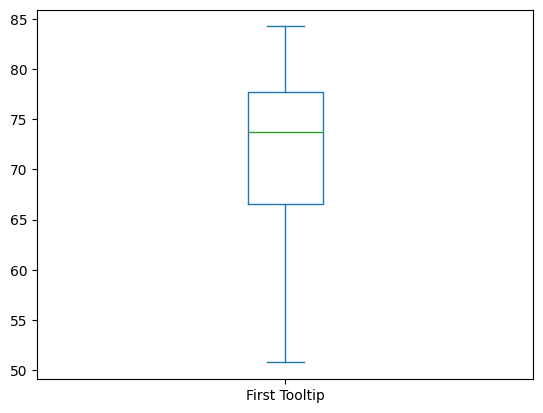

In [62]:
print(filtered_df['First Tooltip'].describe())
filtered_df['First Tooltip'].plot(kind='box')

**Findings:** De gemiddelde levensverwachting in de dataset is 72,5 jaar. Ook is de onderste 'whisker' van de boxplot langer, wat betekent dat de datapunten meer verspreid zijn naar de lagere waarden.

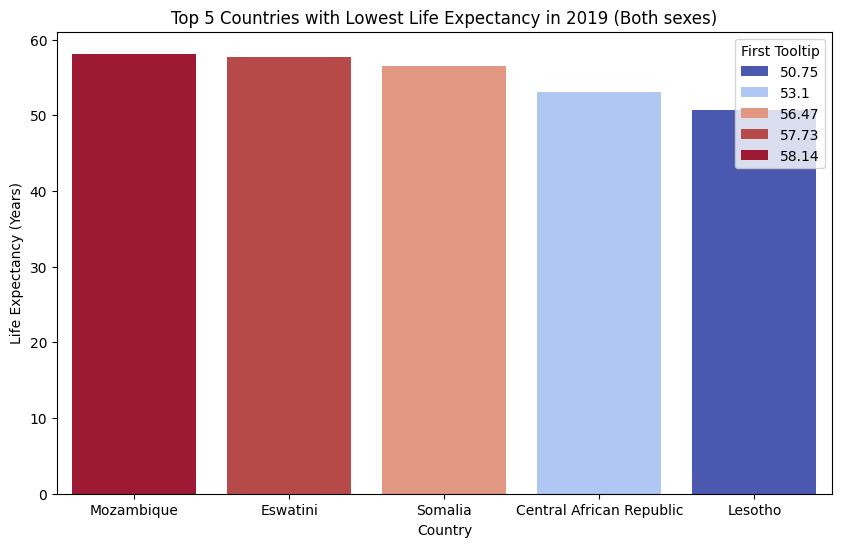

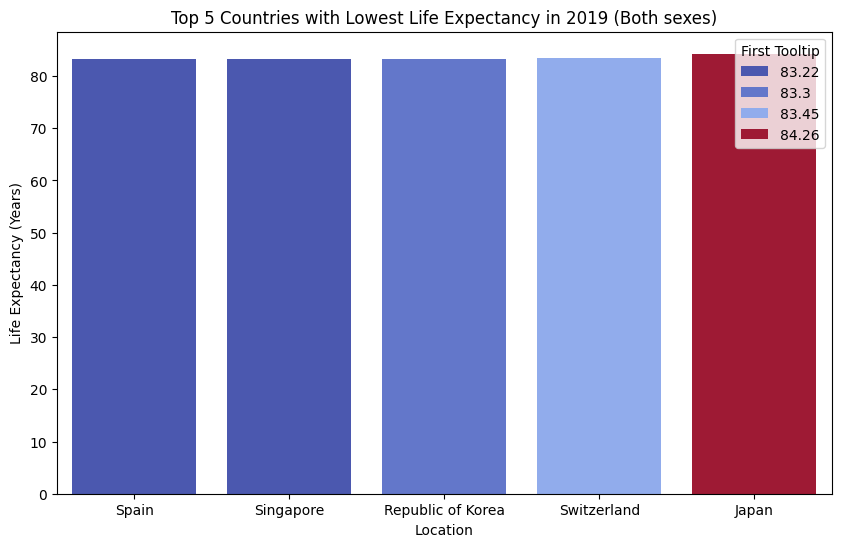

In [88]:
top_5_countries_highest = filtered_df.nlargest(5, 'First Tooltip')[['Location', 'First Tooltip']]
top_5_countries_lowest = filtered_df.nsmallest(5, 'First Tooltip')[['Location', 'First Tooltip']]

top_5_countries_lowest = top_5_countries_lowest.iloc[::-1]
top_5_countries_highest = top_5_countries_highest.iloc[::-1]

# top 5 lowest Life Expectancy
plt.figure(figsize=(10, 6))
sns.barplot(x='Location', y='First Tooltip', data=top_5_countries_lowest, hue='First Tooltip', palette='coolwarm')
plt.title('Top 5 Countries with Lowest Life Expectancy in 2019 (Both sexes)')
plt.ylabel('Life Expectancy (Years)')
plt.xlabel('Country')
plt.show()

# top 5 highest Life Expectancy
plt.figure(figsize=(10, 6))
sns.barplot(x='Location', y='First Tooltip', data=top_5_countries_highest, hue='First Tooltip', palette='coolwarm')
plt.title('Top 5 Countries with Lowest Life Expectancy in 2019 (Both sexes)')
plt.ylabel('Life Expectancy (Years)')
plt.xlabel('Location')
plt.show()

## Portfolio assignment 6

#### Univariate analyse van aanvalstypes

**Assumption:**
Ik ga ervan uit dat phishing de meest voorkomende vorm van cyberaanval is in de dataset, omdat deze aanval relatief eenvoudig uit te voeren is en veel mensen er gemakkelijk in trappen.

Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64


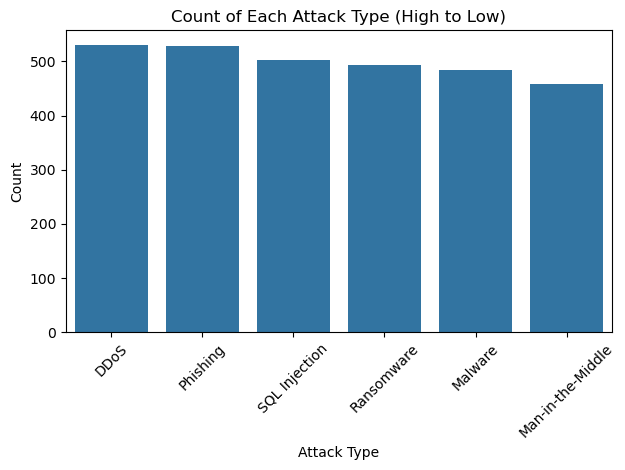

In [14]:
print(cybersecurityThreats["Attack Type"].value_counts())

attack_counts = cybersecurityThreats["Attack Type"].value_counts().reset_index()
attack_counts.columns = ["Attack Type", "Count"]

sns.barplot(
    x="Attack Type",
    y="Count",
    data=attack_counts,
    order=attack_counts["Attack Type"]
)

plt.title("Count of Each Attack Type (High to Low)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings:**
Uit de univariate analyse blijkt dat DDoS-aanvallen het vaakst voorkomen in de dataset, met in totaal 531 geregistreerde aanvallen. In tegenstelling tot mijn verwachting is phishing niet de meest voorkomende aanvalsvorm. De minst voorkomende aanval is een man-in-the-middle-aanval.

#### Univariate analyse van aanvallers

**Assumptions:** Ik ga ervan uit dat de meeste aanvallen in de dataset afkomstig zijn van een onbekende bron, omdat cyberaanvallers vaak hun identiteit of herkomst verbergen.

Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64


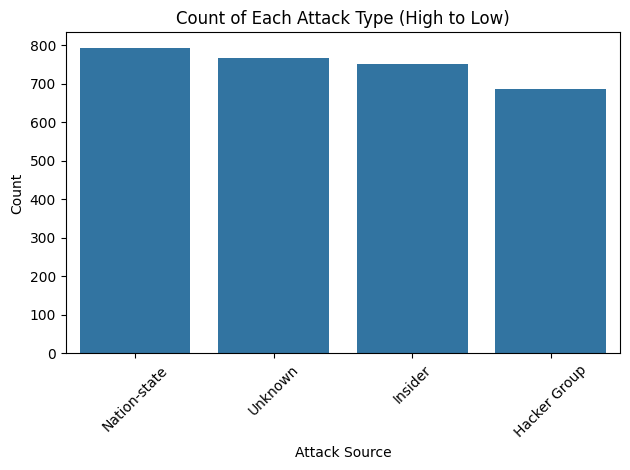

In [9]:
print(cybersecurityThreats["Attack Source"].value_counts())

attack_counts = cybersecurityThreats["Attack Source"].value_counts().reset_index()
attack_counts.columns = ["Attack Source", "Count"]

sns.barplot(
    x="Attack Source",
    y="Count",
    data=attack_counts,
    order=attack_counts["Attack Source"]
)

plt.title("Count of Each Attack Type (High to Low)")
plt.xlabel("Attack Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings:** Mijn aanname blijkt niet juist. Hoewel "Unknown" een van de meest voorkomende aanvalsbronnen is, komt "Nation state" het vaakst voor in de dataset. Dit betekent dat de meeste aanvallen vermoedelijk afkomstig zijn van statelijke actoren—zoals overheden of door de staat gesteunde groepen—die cyberaanvallen inzetten om politieke, economische of militaire doelen te bereiken.

#### Univariate analyse van financiële verliezen (in miljoenen dollars)

**Aanname:** Ik ga ervan uit dat het gemiddelde financiële verlies boven de 40 miljoen dollar ligt, omdat cyberaanvallen aanzienlijke schade kunnen veroorzaken aan bedrijven, wat kan leiden tot verlies van klanten, reputatieschade en hoge herstelkosten.


count    3000.000000
mean       50.492970
std        28.791415
min         0.500000
25%        25.757500
50%        50.795000
75%        75.630000
max        99.990000
Name: Financial Loss (in Million $), dtype: float64


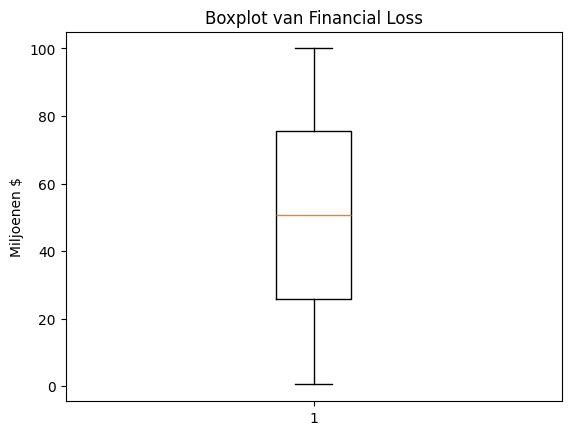

In [14]:
print(cybersecurityThreats["Financial Loss (in Million $)"].describe())

plt.figure()
plt.boxplot(cybersecurityThreats['Financial Loss (in Million $)'])
plt.title('Boxplot van Financial Loss')
plt.ylabel('Miljoenen $')
plt.show()

**Findings:**  
Het gemiddelde financiële verlies bedraagt ongeveer \$50 miljoen. De whiskers in de box‑plot zijn aan beide zijden even lang, wat aangeeft dat de spreiding van de verliezen boven en onder de mediaan vrijwel gelijk is en de verdeling daardoor symmetrisch is.


## Portfolio assignment 7

15 min: Look at the histogram of at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you recognise the distribution? Does it look like a uniform or normal distribution or something else? If it doesn't look like a uniform or normal distribution, take a quick look here to see if you can find the distribution shape: https://www.itl.nist.gov/div898/handbook/eda/section3/eda366.htm

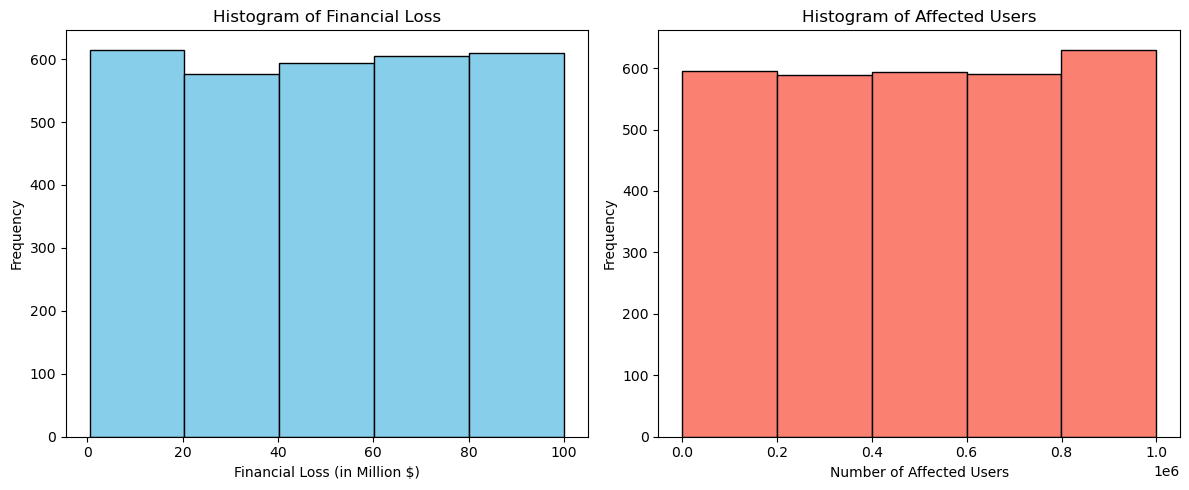

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(cybersecurityThreats['Financial Loss (in Million $)'], bins=5, color='skyblue', edgecolor='black')
plt.title('Histogram of Financial Loss')
plt.xlabel('Financial Loss (in Million $)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(cybersecurityThreats['Number of Affected Users'], bins=5, color='salmon', edgecolor='black')
plt.title('Histogram of Affected Users')
plt.xlabel('Number of Affected Users')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Findings:** Zowel de histogram van ‘Financial Loss’ als die van ‘Number of Affected Users’ ziet er relatief vlak uit, met frequenties die gelijkmatig over de intervallen verdeeld zijn. Dit wijst op een uniforme verdeling.

## Portfolio assignment 8

15 min:

- Calculate the 90%, 95%, 99% and 99.99% confidence interval for at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you see the impact the confidence has on the interval?
- Now calculate the 95% confidence interval again but use only the first 10% of your rows. Compare this interval to the previous 95% confidence interval you calculated. Do you see the impact of having less data?


**Assumption:** Ik denk dat de confidence interval groter wordt naarmate je de zekerheid verhoogt. Ook denk ik dat het confidence interval groter wordt als je een kleinere sample gebruikt.

#### Confidence interval of Financial Loss (in Million $)

In [30]:
confidences = [0.90, 0.95, 0.99, 0.9999]
feature = cybersecurityThreats["Financial Loss (in Million $)"]

for conf in confidences: 
    conf_int = st.t.interval(
        conf,
        len(cybersecurityThreats)-1,
        loc=feature.mean(),
        scale=st.sem(feature)
    )
    print(f"Met {conf}% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen {str(round(conf_int[0], 2))} en {str(round(conf_int[1], 2))}.")
    


Met 0.9% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 49.63 en 51.36.
Met 0.95% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 49.46 en 51.52.
Met 0.99% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 49.14 en 51.85.
Met 0.9999% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 48.45 en 52.54.


In [33]:
first_ten_per = cybersecurityThreats.iloc[:int(len(cybersecurityThreats) * 0.1)]
feature = first_ten_per["Financial Loss (in Million $)"]

conf_int = st.t.interval(
    0.95,
    len(first_ten_per)-1,
    loc=feature.mean(),
    scale=st.sem(feature)
)

print(conf_int)

(49.461197899290035, 56.00626876737663)


#### Confidence interval of Affected Users

In [34]:
confidences = [0.90, 0.95, 0.99, 0.9999]
feature = cybersecurityThreats["Number of Affected Users"]

for conf in confidences: 
    conf_int = st.t.interval(
        conf,
        len(cybersecurityThreats)-1,
        loc=feature.mean(),
        scale=st.sem(feature)
    )
    print(f"Met {conf}% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen {str(round(conf_int[0], 2))} en {str(round(conf_int[1], 2))}.")
    


Met 0.9% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 495974.2 en 513394.07.
Met 0.95% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 494304.62 en 515063.65.
Met 0.99% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 491039.96 en 518328.31.
Met 0.9999% zekerheid schatten we dat het werkelijke gemiddelde ligt tussen 484061.04 en 525307.23.


In [37]:
first_ten_per = cybersecurityThreats.iloc[:int(len(cybersecurityThreats) * 0.1)]
feature = first_ten_per["Number of Affected Users"]

conf_int = st.t.interval(
    0.95,
    len(first_ten_per)-1,
    loc=feature.mean(),
    scale=st.sem(feature)
)

print(conf_int)

(470517.25466826657, 537419.0119984001)


**Findings:** Mijn aanname was correct: naarmate de zekerheid (confidence) toenam, werd het confidence interval inderdaad breder.

## Portfolio assignment 9

25 min: Perform a bivariate analysis on the columns with numerical data in the penguins dataset.

- Use corr() on the DataFrame to calculate all the correlations. Use the code example above to show the correlation table with colors.
- Look at the corrrelations. Do they match your expectations?
- Show a scatter plot for:
    - The strongest positive correlation
    - The strongest negative correlation
    - The weakest correlation


**Assumption:** Ik verwacht dat er een sterke correlatie is tussen de flipper length en de body mass, omdat een langer lichaamsdeel meestal samengaat met een zwaarder lichaam bij pinguïns.

In [4]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


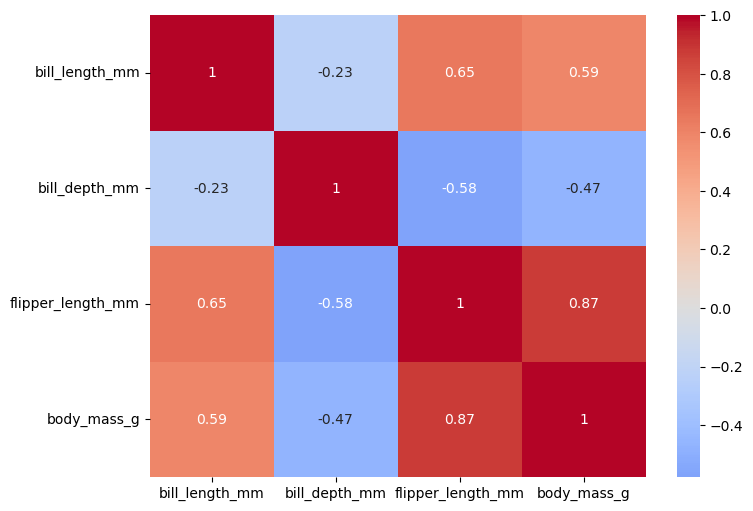

In [7]:
penguins_clean = penguins.dropna()

num_data = penguins_clean.select_dtypes(include='number')

correlation_matrix = num_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

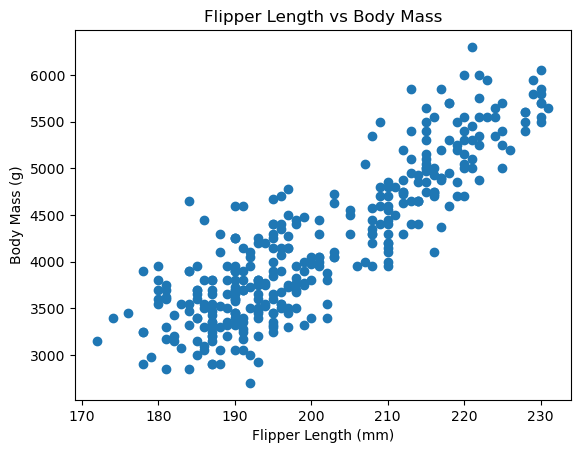

In [12]:
plt.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])
plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

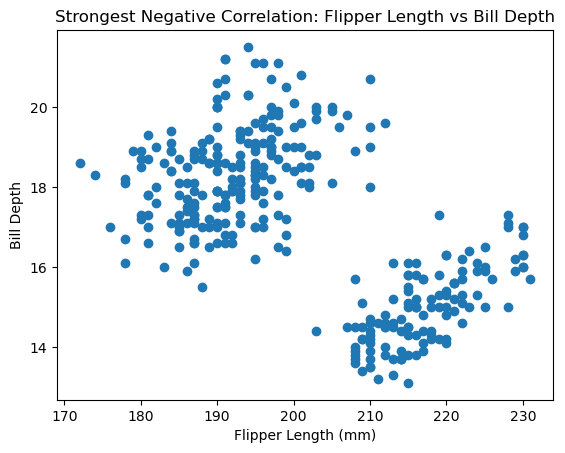

In [14]:
plt.scatter(penguins["flipper_length_mm"], penguins["bill_depth_mm"])
plt.title('Strongest Negative Correlation: Flipper Length vs Bill Depth')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Depth')
plt.show()

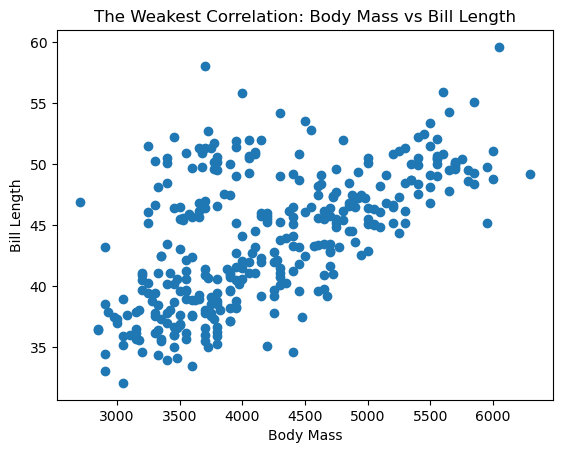

In [21]:
plt.scatter(penguins["body_mass_g"], penguins["bill_length_mm"])
plt.title('The Weakest Correlation: Body Mass vs Bill Length')
plt.xlabel('Body Mass')
plt.ylabel('Bill Length')
plt.show()

**Findings:** De correlatie tussen flipper length en body mass is inderdaad het hoogst, dus mijn aanname bleek correct te zijn. Ook zien 

## Portfolio assignment 10

15 min: Perform a bivariate analysis (Pearson correlation and scatter plot) on at least 1 combination of 2 columns with numeric data in the dataset that you chose in portfolio assignment 4. Does the correlation and scatter plot match your expectations? Add your answer to your notebook. Commit the Notebook to your portfolio when you're finished.

**Assumption:** Ik denk dat er een sterke positieve correlatie bestaat tussen het financiële verlies (in miljoenen) en het aantal uren dat nodig is om een incident op te lossen. Mijn redenatie hierbij is dat hoe meer tijd het kost om een incident op te lossen, des te groter en kostbaarder het probleem waarschijnlijk is geweest.

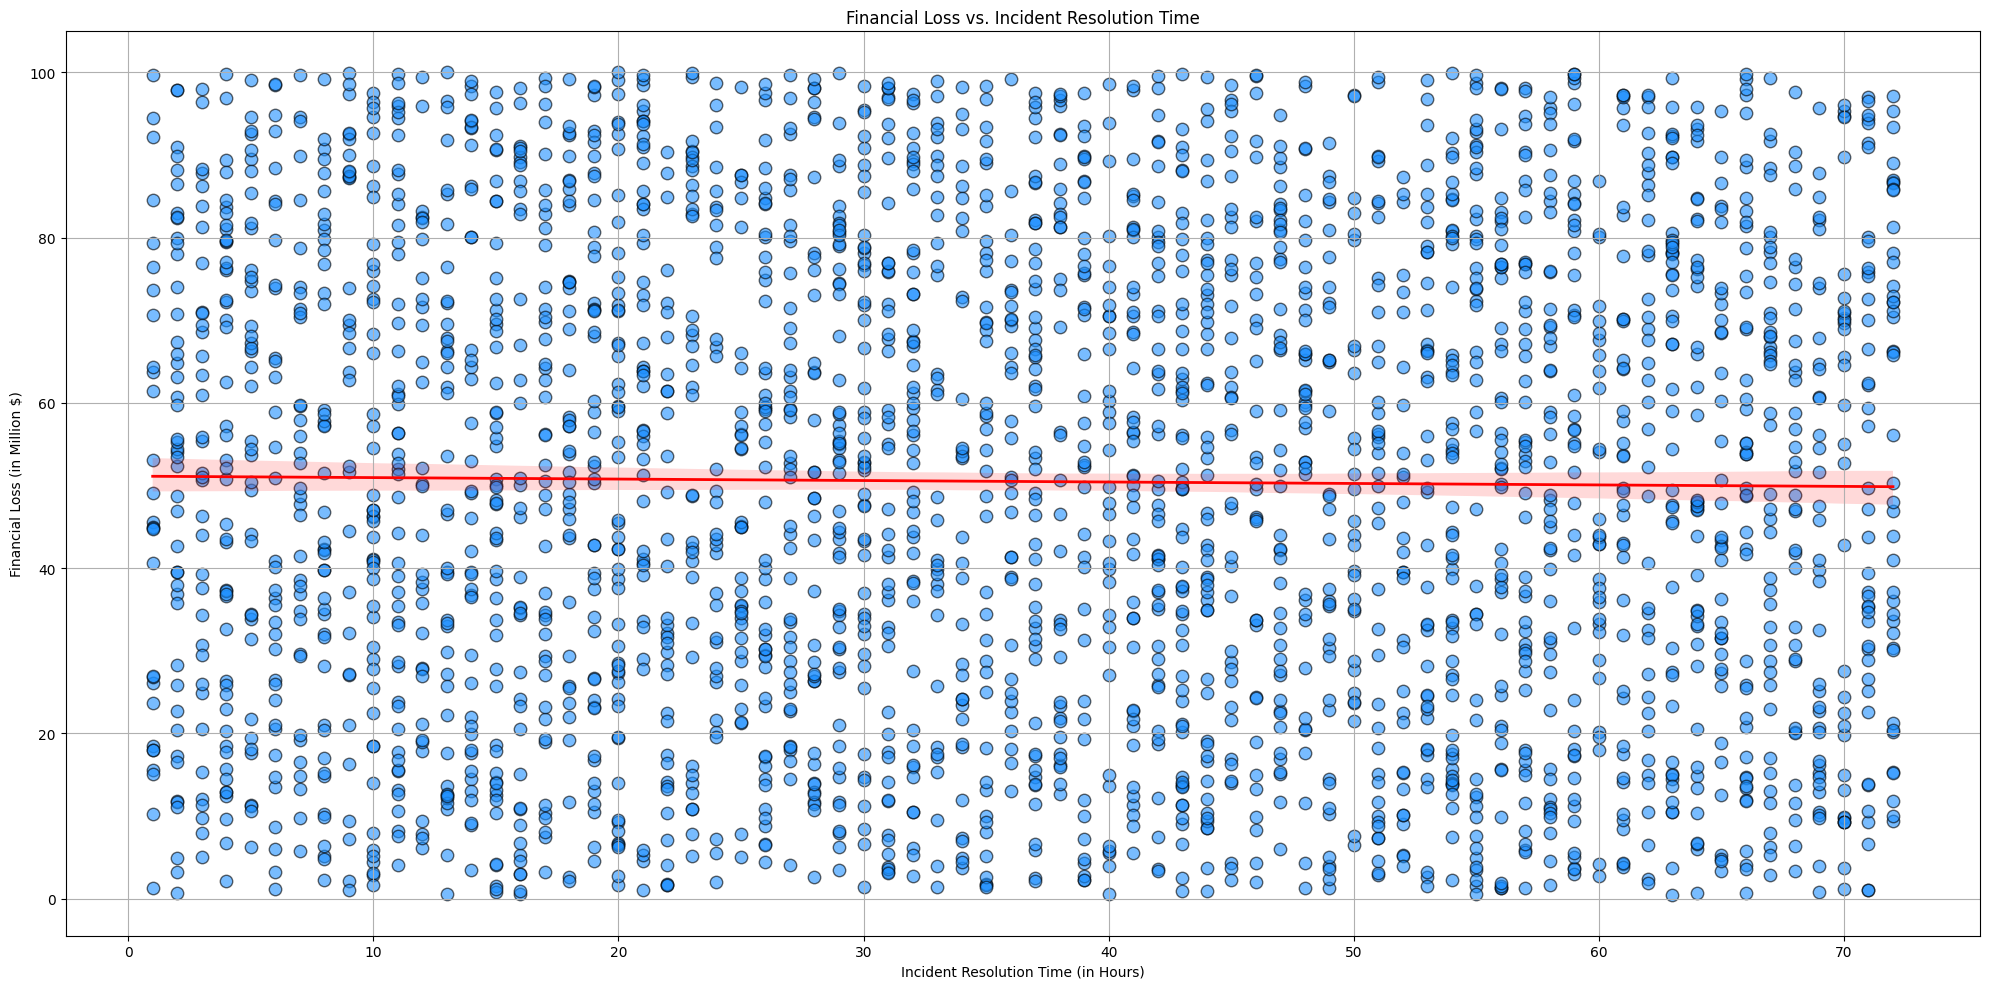

The Pearson correlation coefficient is -0.012670791107337306


In [7]:
plt.figure(figsize=(20, 10))

sns.regplot(
    x="Incident Resolution Time (in Hours)",
    y="Financial Loss (in Million $)",
    data=cybersecurityThreats,
    scatter_kws={"s": 80, "alpha": 0.6, "color": "dodgerblue", "edgecolor": "black"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Financial Loss vs. Incident Resolution Time")
plt.xlabel("Incident Resolution Time (in Hours)")
plt.ylabel("Financial Loss (in Million $)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"The Pearson correlation coefficient is {cybersecurityThreats["Financial Loss (in Million $)"].corr(cybersecurityThreats["Incident Resolution Time (in Hours)"])}")

**Findings:** Uit de analyse blijkt dat mijn aanname onjuist was. Er is geen sprake van een correlatie tussen de financiële schade en de tijd die nodig is om het incident op te lossen.

## Portfolio assignment 11

20 min: Do a Numerical VS Categorical bivariate analysis on the penguins dataset.

- Choose one of the categorical columns: species, island or sex
- use .groupby('').mean() too look at the means of the numerical columns. Does it look like there is a difference between categories?
-Use the seaborn barplot to plot the mean and confidence. Create this plot for each of the numerical columns (bill_length_mm bill_depth_mm, flipper_length_mm, body_mass_g)
- For each of the plots, write a conclusion: Is there a statistically significant difference for this numerical column for each category?
- Optional: Repeat this proces for the other two categorical columns


**Assumptions:** Ik vermoed dat het gemiddelde gewichtsverschil tussen mannen en vrouwen groot is, omdat dit bij de meeste diersoorten ook zo is vanwege verschillen in spiermassa

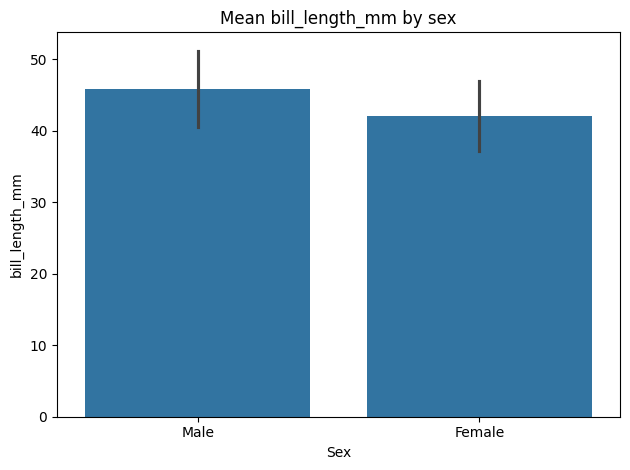

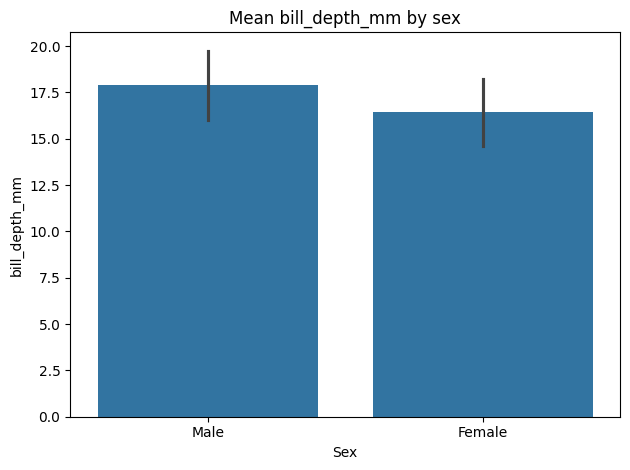

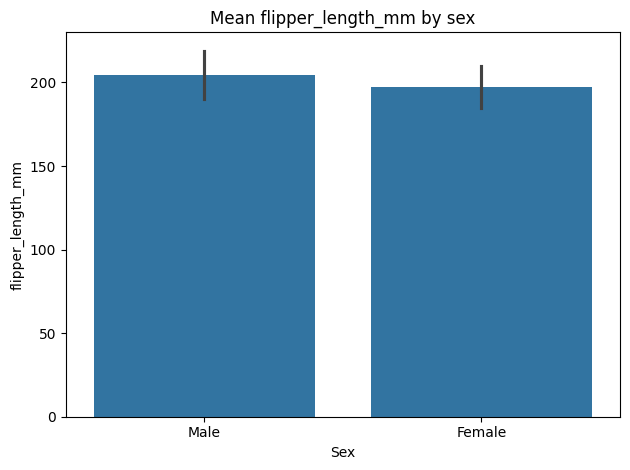

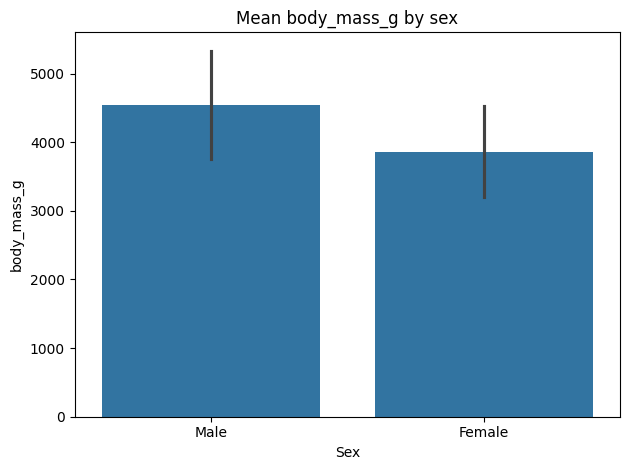

In [69]:
penguins = sns.load_dataset("penguins")

numeric_cols = penguins.select_dtypes(include="number").columns
penguins.groupby("sex")[numeric_cols].mean()


for col in numeric_cols:
    plt.figure()
    sns.barplot(x="sex", y=col, data=penguins, errorbar='sd')
    plt.title(f"Mean {col} by sex")
    plt.ylabel(f"{col}")
    plt.xlabel("Sex")
    plt.tight_layout()
    plt.show()



**Findings:** Bij het vergelijken van de gemiddelde waarden van de numerieke features tussen de seksen van pinguïns, blijkt dat de confidence intervals telkens overlappen. Dit wijst erop dat er geen significant verschil is tussen de gemiddelden van mannelijke en vrouwelijke pinguïns voor deze kenmerken

## Portfolio assignment 12

30 min: Perform a bivariate analysis on at least 3 combinations of a numerical column with a categorical column in the dataset that you chose in portfolio assignment 4. Use .groupby('columnname').mean() to calculate the means. Is there a difference between categories? Then use seaborn barplots to check if there is a statistically significant difference.

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Attack Type,,,,
DDoS,2019.472693,52.035631,499437.410546,35.687382
Malware,2019.591753,49.418454,508780.232990,37.074227
Man-in-the-Middle,2019.531590,51.309085,520064.320261,36.871460
Phishing,2019.527410,50.459905,487179.536862,35.913043
Ransomware,2019.711968,49.653793,502825.369168,36.533469
SQL Injection,2019.594433,50.013042,512469.833002,36.906561


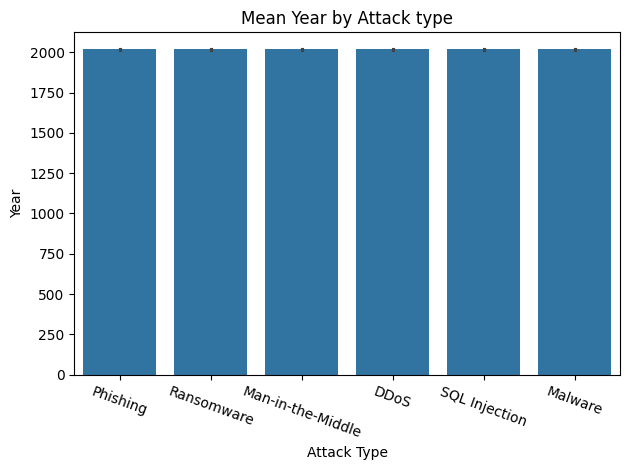

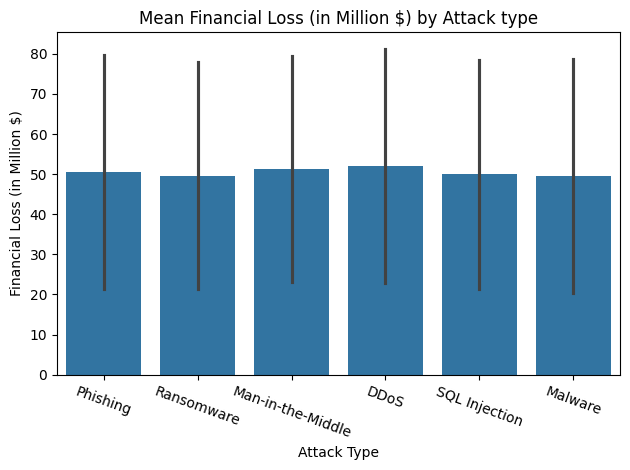

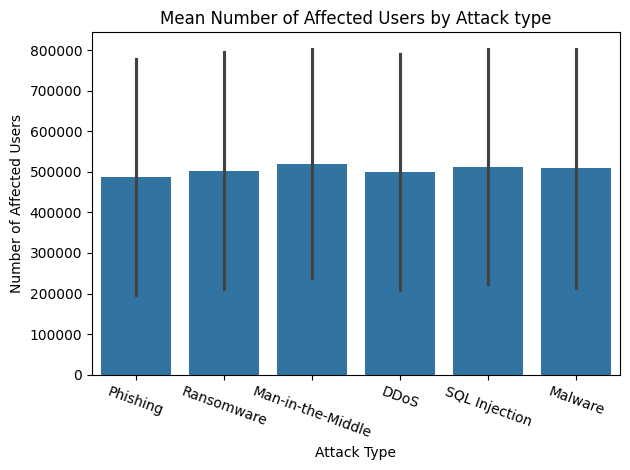

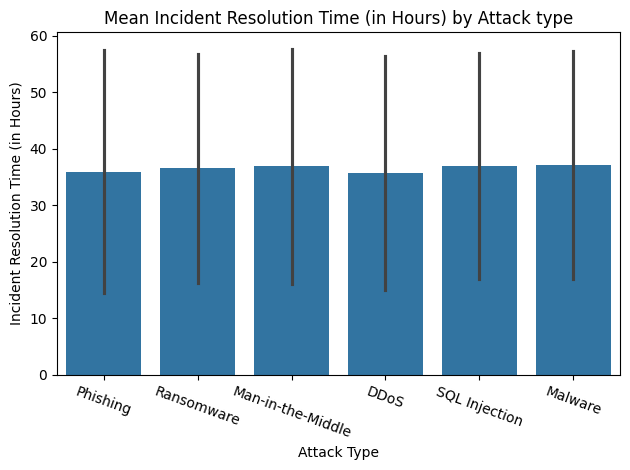

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Country,,,,
Australia,2019.707071,51.861953,505090.336700,36.481481
Brazil,2019.600000,50.911677,544538.645161,37.761290
China,2019.857651,48.805943,496729.316726,37.398577
France,2019.360656,49.089443,512226.695082,36.216393
Germany,2019.594502,54.272302,507475.457045,36.017182
India,2019.587662,47.292597,484346.295455,35.931818
Japan,2019.678689,49.827344,487579.718033,37.098361
Russia,2019.600000,49.948237,515904.525424,35.535593
UK,2019.457944,51.411184,490545.118380,36.925234


In [97]:


numeric_cols = cybersecurityThreats.select_dtypes(include="number").columns



display(cybersecurityThreats.groupby("Attack Type")[numeric_cols].mean())

for col in numeric_cols:
    plt.figure()
    sns.barplot(x="Attack Type", y=col, data=cybersecurityThreats, errorbar='sd')
    plt.title(f"Mean {col} by Attack type")
    plt.ylabel(f"{col}")
    plt.xlabel("Attack Type")
    plt.xticks(rotation=-20)
    plt.tight_layout()
    plt.show()
cybersecurityThreats.groupby("Target Industry")[numeric_cols].mean()


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Target Industry,,,,
Banking,2019.496629,51.173910,505839.114607,35.737079
Education,2019.556086,47.903174,513137.785203,35.906921
Government,2019.543424,52.618685,499352.431762,37.593052
Healthcare,2019.484848,49.047296,504130.340326,35.806527
IT,2019.504184,51.903410,523210.939331,36.169456
Retail,2019.683215,49.928014,488833.063830,37.219858
Telecommunications,2019.744417,50.766973,495203.746898,37.062035


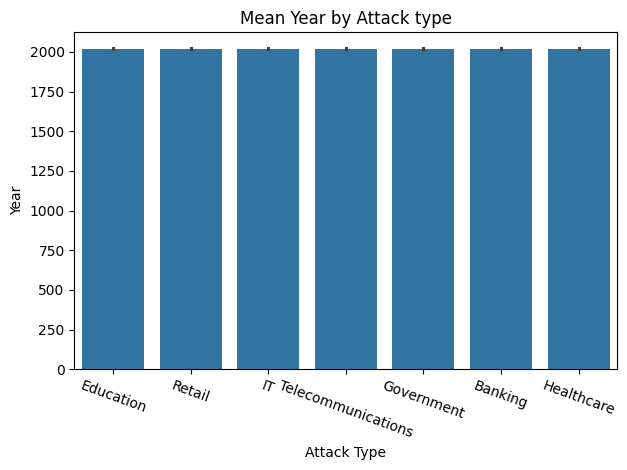

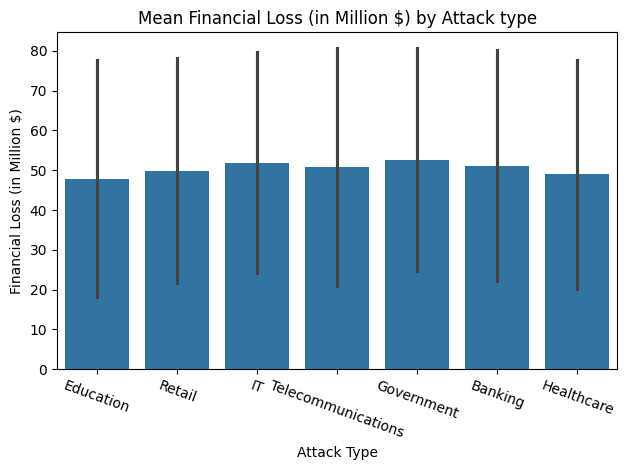

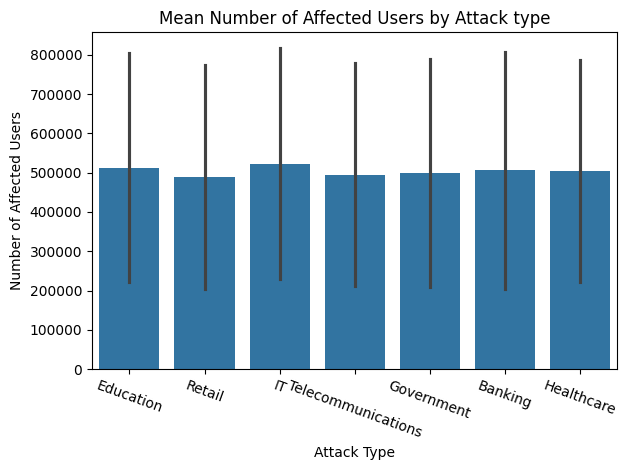

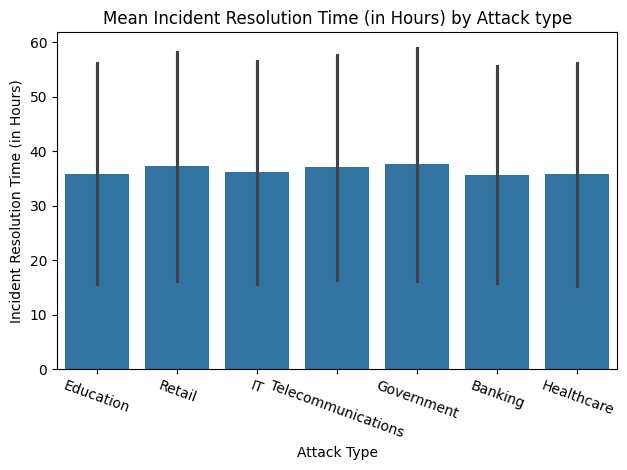

In [101]:
display(cybersecurityThreats.groupby("Target Industry")[numeric_cols].mean())

for col in numeric_cols:
    plt.figure()
    sns.barplot(x="Target Industry", y=col, data=cybersecurityThreats, errorbar='sd')
    plt.title(f"Mean {col} by Attack type")
    plt.ylabel(f"{col}")
    plt.xlabel("Attack Type")
    plt.xticks(rotation=-20)
    plt.tight_layout()
    plt.show()

In [103]:
display(cybersecurityThreats.groupby("Country")[numeric_cols].mean())


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Country,,,,
Australia,2019.707071,51.861953,505090.336700,36.481481
Brazil,2019.600000,50.911677,544538.645161,37.761290
China,2019.857651,48.805943,496729.316726,37.398577
France,2019.360656,49.089443,512226.695082,36.216393
Germany,2019.594502,54.272302,507475.457045,36.017182
India,2019.587662,47.292597,484346.295455,35.931818
Japan,2019.678689,49.827344,487579.718033,37.098361
Russia,2019.600000,49.948237,515904.525424,35.535593
UK,2019.457944,51.411184,490545.118380,36.925234
